In [11]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from ipywidgets import interact, IntSlider
initialise_or_create_database_at("./2026-05-11_SNSPD12.db")
import snspd
params = snspd.snspd('snspd12.yaml')

# Set up experiment
exp_name = 'SNSPD12_29_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 315


In [2]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd12.yaml')

Text(0.5, 0, 'Current (A)')

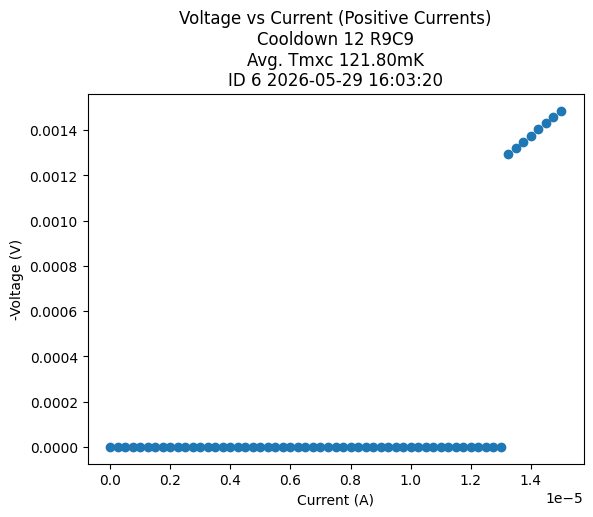

In [10]:
ID = 6
data = load_by_id(ID).get_parameter_data()
current = data['dmm_volt']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
MC_temp = data['MC_temp']['MC_temp']
plt.plot(current, -voltage, 'o')
plt.title(params.make_title(ID=ID, title=f'Voltage vs Current (Positive Currents)\nCooldown 12 {params.device_line_1['name']}\nAvg. Tmxc {np.average(MC_temp)*1e3:.2f}mK'))
plt.xlabel('Current (A)')
plt.ylabel('-Voltage (V)')
plt.xlabel('Current (A)')

# Note it was accidental to connect so that a positive current had to be applied to see a positive puls
# Usually a negative current has to be applied to see a pulse 

In [17]:
# get peak 
from scipy.signal import find_peaks
import numpy as np

def plot_traces(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(params.trace_v_trigger), distance=1000)
    plt.plot(taxis, np.ones_like(taxis)*float(params.trace_v_trigger), label='Trigger in sweep')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.title(params.make_title(ID=ID, title=f'Current: {current[0]}\nCooldown 12'))
    plt.legend()
    print(current, trace[peaks], 0.8*trace[peaks], 0.5*trace[peaks])

interact(plot_traces, ID=IntSlider(min_id=8, max_id=68, step=1, value=8,
                                  continuous_update=False));

interactive(children=(IntSlider(value=8, continuous_update=False, description='ID'), Output()), _dom_classes=(…

In [18]:
params.trace_h_time

'3e-6'

In [31]:
# get peak 
from scipy.signal import find_peaks
import numpy as np

def plot_traces(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(params.trace_v_trigger), distance=1000)
    plt.plot(taxis, np.ones_like(taxis)*48e-3, label='Trigger in sweep')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.legend()
    print(current, trace[peaks], 0.8*trace[peaks], 0.5*trace[peaks])

interact(plot_traces, ID=IntSlider(min_id=76, max_idx=93, step=1, value=8,
                                  continuous_update=False));

interactive(children=(IntSlider(value=8, continuous_update=False, description='ID'), Output()), _dom_classes=(…

In [24]:
peaks

array([188])

In [ ]:
plt.plot(taxis, np.ones_like(taxis)*float(0.03), label='New trigger')

(0.0, 5e-06)

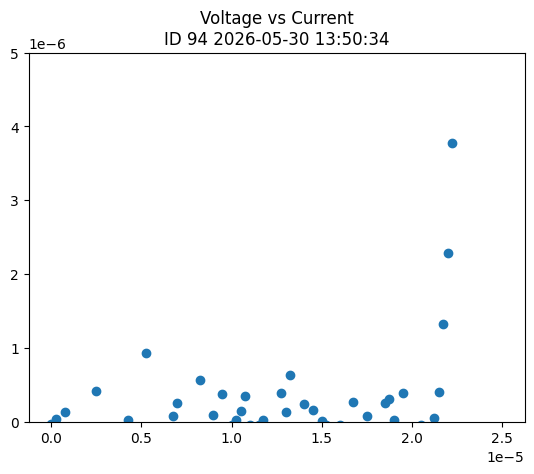

In [45]:
ID = 94
data = load_by_id(ID).get_parameter_data()
current = data['dmm_volt']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
plt.plot(current, voltage, 'o')
plt.title(params.make_title(ID=ID, title='Voltage vs Current'))
plt.ylim([0, 0.5e-5])

Text(0.5, 1.0, 'Voltage vs Current\nID 95 2026-05-30 14:16:36')

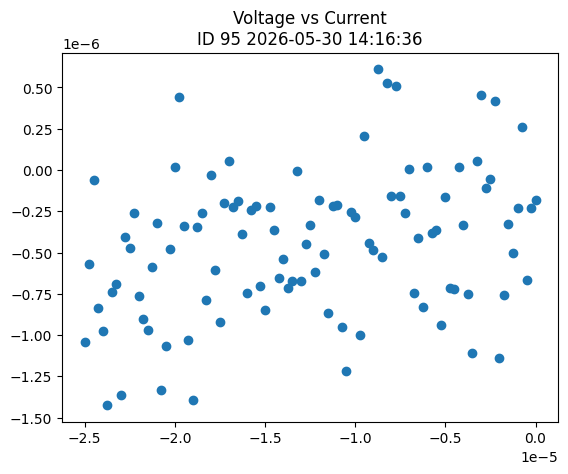

In [44]:
ID = 95
data = load_by_id(ID).get_parameter_data()
current = data['dmm_volt']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
plt.plot(current, voltage, 'o')
plt.title(params.make_title(ID=ID, title='Voltage vs Current'))

Text(0.5, 1.0, 'Voltage vs Current\nID 96 2026-05-30 15:02:33')

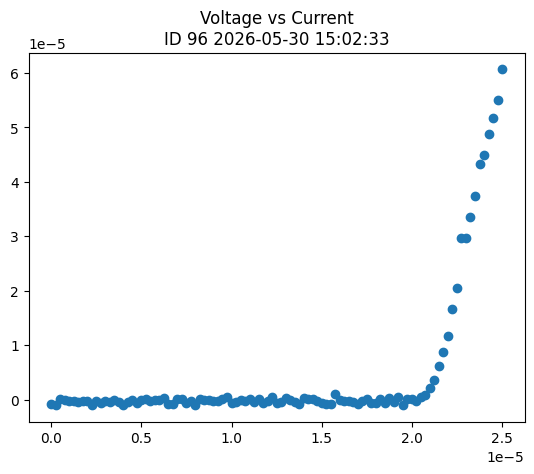

In [43]:
ID = 96
data = load_by_id(ID).get_parameter_data()
current = data['dmm_volt']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
plt.plot(current, voltage, 'o')
plt.title(params.make_title(ID=ID, title='Voltage vs Current'))

Text(0.5, 1.0, 'Voltage vs Current\nID 97 2026-05-30 17:34:51')

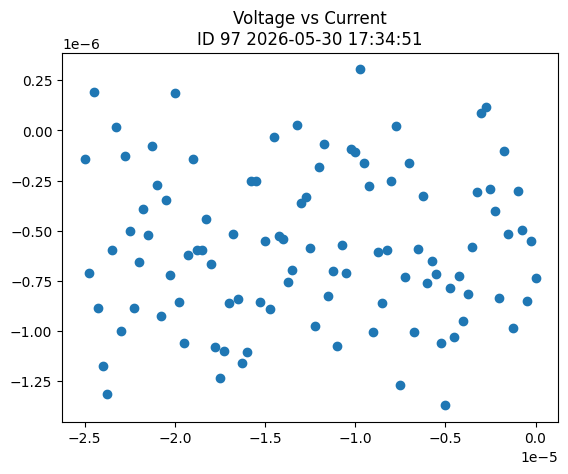

In [46]:
ID = 97
data = load_by_id(ID).get_parameter_data()
current = data['dmm_volt']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
plt.plot(current, voltage, 'o')
plt.title(params.make_title(ID=ID, title='Voltage vs Current'))